# Numerical Calculus in 1D: Derivatives & Integrals

This notebook implements and analyzes numerical differentiation and integration for five mathematical functions.<br>
Original code in C **[assign3.c](https://github.com/jennarhae16/SDSU/blob/main/COMP526/assign3.c)** for ***COMP 526: Computational Methods for Scientist***. It has been translated to Python for accessibility.<br>

[Original Assignment PDF](https://github.com/jennarhae16/SDSU/blob/main/COMP526/assignment3.pdf)<br>

It demonstrates:

- **Adaptive step size selection** for centered finite differences
- **Trapezoidal rule** for numerical integration
- **Error analysis** comparing approximations to exact closed-form results
- **Convergence study** showing how accuracy improves with more subintervals

### Functions covered
| Index | Function | Domain |
|-------|----------|--------|
| 1 | Natural logarithm $\ln(x)$ | $(0, \infty)$ |
| 2 | Tangent $\tan(x)$ | excludes $x = \pi/2 + k\pi$ |
| 3 | Arcsine $\arcsin(x)$ | $[-1, 1]$ |
| 4 | Hyperbolic cosine $\cosh(x)$ | $\mathbb{R}$ |
| 5 | Hyperbolic arctangent $\text{arctanh}(x)$ | $(-1, 1)$ |

### Method: Adaptive Centered Finite Difference

The derivative at each interior point $x_j$ is approximated by:
$$f'(x_j) \approx \frac{f(x_j + dH) - f(x_j - dH)}{2\,dH}$$

where the step size $dH$ balances truncation and floating-point cancellation error:
$$dh(x) = 2\sqrt{\varepsilon \left|\frac{f(x)}{f''(x)}\right|}, \quad dH(x) = \min\!\left(dh(x),\, \frac{b-a}{2n}\right), \quad \varepsilon = 10^{-16}$$

### Method: Trapezoidal Rule
$$\int_a^b f(x)\,dx \approx \frac{b-a}{n}\left(\frac{f(a)}{2} + \sum_{k=1}^{n-1} f\!\left(a + k\frac{b-a}{n}\right) + \frac{f(b)}{2}\right)$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import Callable

EPSILON = 1e-16   # machine epsilon proxy for float64

In [2]:
# ── Function registry ──────────────────────────────────────────────────────────
# Each entry defines f, f', f'', antiderivative F, and a valid default interval.

@dataclass
class FunctionSpec:
    name: str
    f:    Callable
    df:   Callable   # first derivative  (exact)
    d2f:  Callable   # second derivative (used for adaptive dh)
    F:    Callable   # antiderivative    (used for exact integral)
    default_interval: tuple


FUNCTIONS = {
    1: FunctionSpec(
        name="Natural Logarithm  ln(x)",
        f   = np.log,
        df  = lambda x: 1.0 / x,
        d2f = lambda x: -1.0 / x**2,
        F   = lambda x: x * np.log(x) - x,
        default_interval=(0.5, 3.0),
    ),
    2: FunctionSpec(
        name="Tangent  tan(x)",
        f   = np.tan,
        df  = lambda x: 1.0 / np.cos(x)**2,
        d2f = lambda x: 2.0 * np.sin(x) / np.cos(x)**3,
        F   = lambda x: -np.log(np.abs(np.cos(x))),
        default_interval=(0.1, 1.2),
    ),
    3: FunctionSpec(
        name="Arcsine  arcsin(x)",
        f   = np.arcsin,
        df  = lambda x: 1.0 / np.sqrt(1 - x**2),
        d2f = lambda x: x / (1 - x**2)**1.5,
        F   = lambda x: x * np.arcsin(x) + np.sqrt(1 - x**2),
        default_interval=(-0.8, 0.8),
    ),
    4: FunctionSpec(
        name="Hyperbolic Cosine  cosh(x)",
        f   = np.cosh,
        df  = np.sinh,
        d2f = np.cosh,                          # cosh'' = cosh
        F   = np.sinh,
        default_interval=(-2.0, 2.0),
    ),
    5: FunctionSpec(
        name="Hyperbolic Arctangent  arctanh(x)",
        f   = np.arctanh,
        df  = lambda x: 1.0 / (1 - x**2),
        d2f = lambda x: 2.0 * x / (1 - x**2)**2,
        F   = lambda x: 0.5 * np.log(1 - x**2) + x * np.arctanh(x),
        default_interval=(-0.8, 0.8),
    ),
}

In [3]:
# ── Adaptive step size ─────────────────────────────────────────────────────────

def adaptive_dH(x, f, d2f, a, b, n):
    """
    Compute the adaptive step size dH for centered finite differences.

    dh(x) = 2 * sqrt(eps * |f(x) / f''(x)|)  — balances truncation vs roundoff
    dH(x) = min(dh(x), (b-a)/(2n))            — caps at half the subinterval width

    Parameters
    ----------
    x   : array of interior evaluation points
    f   : function
    d2f : second derivative of f
    a, b: interval endpoints
    n   : number of subintervals
    """
    ratio = np.abs(f(x) / d2f(x))
    dh    = 2.0 * np.sqrt(EPSILON * ratio)
    cap   = (b - a) / (2 * n)
    return np.minimum(dh, cap)


# ── Centered finite difference derivative ─────────────────────────────────────

def approx_derivative(x, dH, f):
    """Centered difference: (f(x+dH) - f(x-dH)) / (2*dH)"""
    return (f(x + dH) - f(x - dH)) / (2.0 * dH)


# ── Trapezoidal rule ───────────────────────────────────────────────────────────

def trapezoidal(f, a, b, n):
    """
    Approximate integral of f on [a, b] using the trapezoidal rule with n panels.
    Returns the approximation and the array of evaluation points.
    """
    x    = np.linspace(a, b, n + 1)   # n+1 points → n panels
    fx   = f(x)
    h    = (b - a) / n
    approx = h * (fx[0] / 2.0 + fx[1:-1].sum() + fx[-1] / 2.0)
    return approx, x

In [4]:
# ── Single-function analysis ───────────────────────────────────────────────────

def analyze(func_id: int, a: float, b: float, n: int, verbose: bool = True):
    """
    Run derivative and integral analysis for one function on [a, b] with n panels.

    Returns a dict with all computed arrays and scalar results.
    """
    spec = FUNCTIONS[func_id]

    # Interior evaluation points x_j, j = 1 … n-1
    xj      = np.linspace(a, b, n + 1)[1:-1]

    # Adaptive step and derivative approximation
    dH      = adaptive_dH(xj, spec.f, spec.d2f, a, b, n)
    approx  = approx_derivative(xj, dH, spec.f)
    exact   = spec.df(xj)
    deriv_err = np.abs(exact - approx)

    # Trapezoidal integral
    approx_int = trapezoidal(spec.f, a, b, n)[0]
    exact_int  = spec.F(b) - spec.F(a)
    int_err    = abs(exact_int - approx_int)

    if verbose:
        print(f"\n{'='*70}")
        print(f"  {spec.name}   |   n={n}   |   [{a}, {b}]")
        print(f"{'='*70}")
        df = pd.DataFrame({
            'x_j':               xj,
            'exact  f\u2032(x)': exact,
            'approx f\u2032(x)': approx,
            '|error|':           deriv_err,
            'dH used':           dH,
        })
        print(df.to_string(index=False, float_format='{:.6e}'.format))
        print(f"\nTrapezoidal integral")
        print(f"  Exact  : {exact_int:.10f}")
        print(f"  Approx : {approx_int:.10f}")
        print(f"  Error  : {int_err:.4e}")

    return dict(
        xj=xj, dH=dH, approx=approx, exact=exact, deriv_err=deriv_err,
        approx_int=approx_int, exact_int=exact_int, int_err=int_err,
    )

In [5]:
# ── Run analysis for all 5 functions at n=20 ──────────────────────────────────
N = 20

all_results = {}
for fid, spec in FUNCTIONS.items():
    a, b = spec.default_interval
    all_results[fid] = analyze(fid, a, b, N)


  Natural Logarithm  ln(x)   |   n=20   |   [0.5, 3.0]
         x_j  exact  f′(x)  approx f′(x)      |error|      dH used
6.250000e-01  1.600000e+00  1.600000e+00 5.349399e-09 8.569601e-09
7.500000e-01  1.333333e+00  1.333333e+00 4.374404e-09 8.045400e-09
8.750000e-01  1.142857e+00  1.142857e+00 7.584534e-09 6.394841e-09
1.000000e+00  1.000000e+00           NaN          NaN 0.000000e+00
1.125000e+00  8.888889e-01  8.888889e-01 6.567007e-09 7.721895e-09
1.250000e+00  8.000000e-01  8.000000e-01 5.568091e-09 1.180952e-08
1.375000e+00  7.272727e-01  7.272727e-01 3.264442e-09 1.551872e-08
1.500000e+00  6.666667e-01  6.666667e-01 2.997980e-10 1.910284e-08
1.625000e+00  6.153846e-01  6.153846e-01 5.368346e-10 2.264548e-08
1.750000e+00  5.714286e-01  5.714286e-01 1.517487e-09 2.618262e-08
1.875000e+00  5.333333e-01  5.333333e-01 8.835438e-10 2.973182e-08
2.000000e+00  5.000000e-01  5.000000e-01 1.232973e-10 3.330218e-08
2.125000e+00  4.705882e-01  4.705882e-01 2.116511e-09 3.689851e-08
2.2500

/var/folders/dr/sztjlnss7h7fz_5nwh6bn0xm0000gn/T/ipykernel_8587/699321132.py:28: RuntimeWarning: invalid value encountered in divide
  return (f(x + dH) - f(x - dH)) / (2.0 * dH)
/var/folders/dr/sztjlnss7h7fz_5nwh6bn0xm0000gn/T/ipykernel_8587/699321132.py:18: RuntimeWarning: invalid value encountered in divide
  ratio = np.abs(f(x) / d2f(x))
/var/folders/dr/sztjlnss7h7fz_5nwh6bn0xm0000gn/T/ipykernel_8587/699321132.py:18: RuntimeWarning: invalid value encountered in divide
  ratio = np.abs(f(x) / d2f(x))


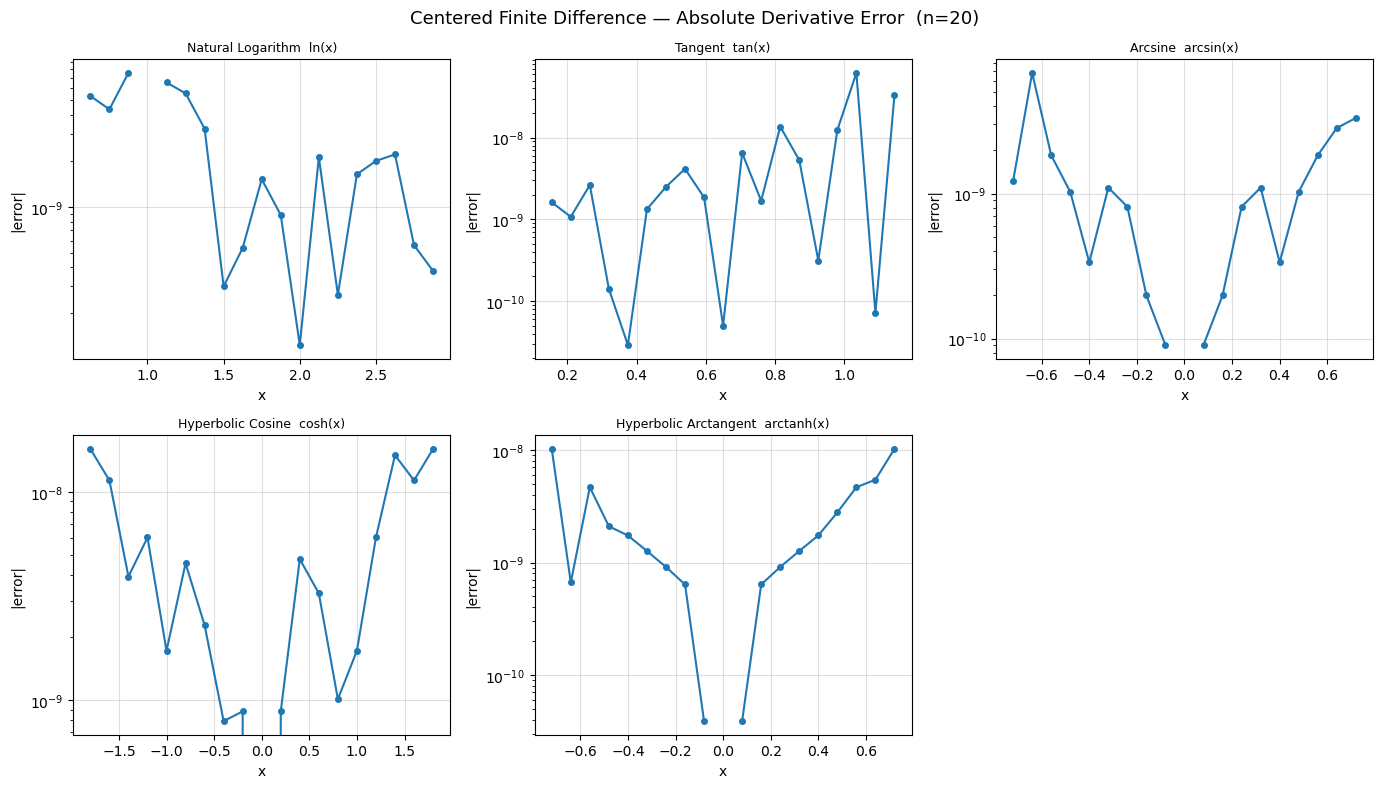

In [7]:
# ── Plot 1: Derivative error for all functions ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle(f'Centered Finite Difference — Absolute Derivative Error  (n={N})', fontsize=13)

for idx, (fid, res) in enumerate(all_results.items()):
    ax = axes[idx]
    ax.semilogy(res['xj'], res['deriv_err'], 'o-', ms=4, lw=1.5)
    ax.set_title(FUNCTIONS[fid].name, fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('|error|')
    ax.grid(alpha=0.4)

axes[-1].set_visible(False)   # hide 6th panel
plt.tight_layout()
plt.savefig('derivative_errors.png', dpi=150, bbox_inches='tight')
plt.show()

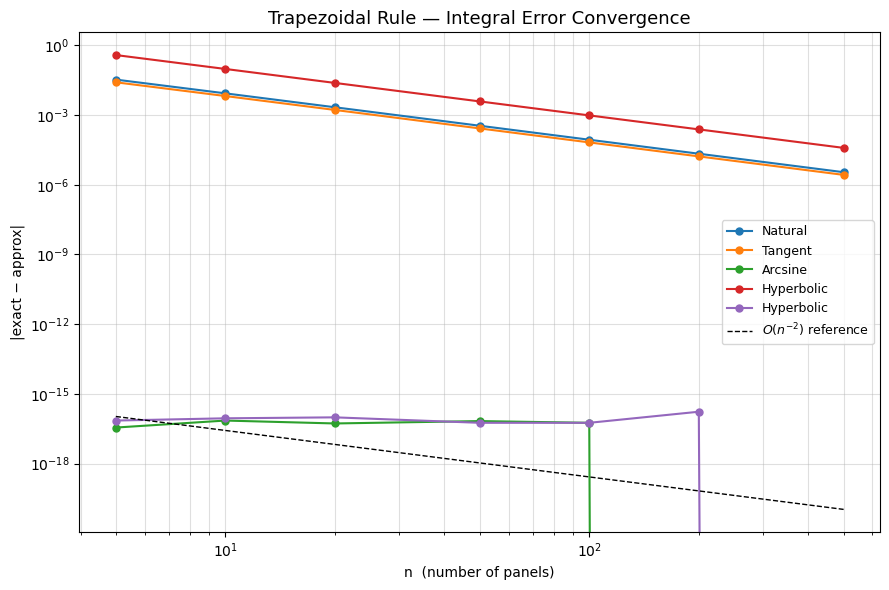

In [8]:
# ── Plot 2: Convergence study — integral error vs n ────────────────────────────
# For the trapezoidal rule on smooth functions, error ~ O(h²) = O(1/n²)

ns = np.array([5, 10, 20, 50, 100, 200, 500])

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Trapezoidal Rule — Integral Error Convergence', fontsize=13)

for fid, spec in FUNCTIONS.items():
    a, b = spec.default_interval
    errors = []
    for n in ns:
        approx_int = trapezoidal(spec.f, a, b, n)[0]
        exact_int  = spec.F(b) - spec.F(a)
        errors.append(abs(exact_int - approx_int))
    ax.loglog(ns, errors, 'o-', ms=5, lw=1.5, label=spec.name.split()[0])

# Reference O(1/n²) line
ref = 1.0 / ns**2
ax.loglog(ns, ref * (errors[0] / ref[0] * 1.5), 'k--', lw=1, label=r'$O(n^{-2})$ reference')

ax.set_xlabel('n  (number of panels)')
ax.set_ylabel('|exact − approx|')
ax.legend(fontsize=9)
ax.grid(alpha=0.4, which='both')
plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

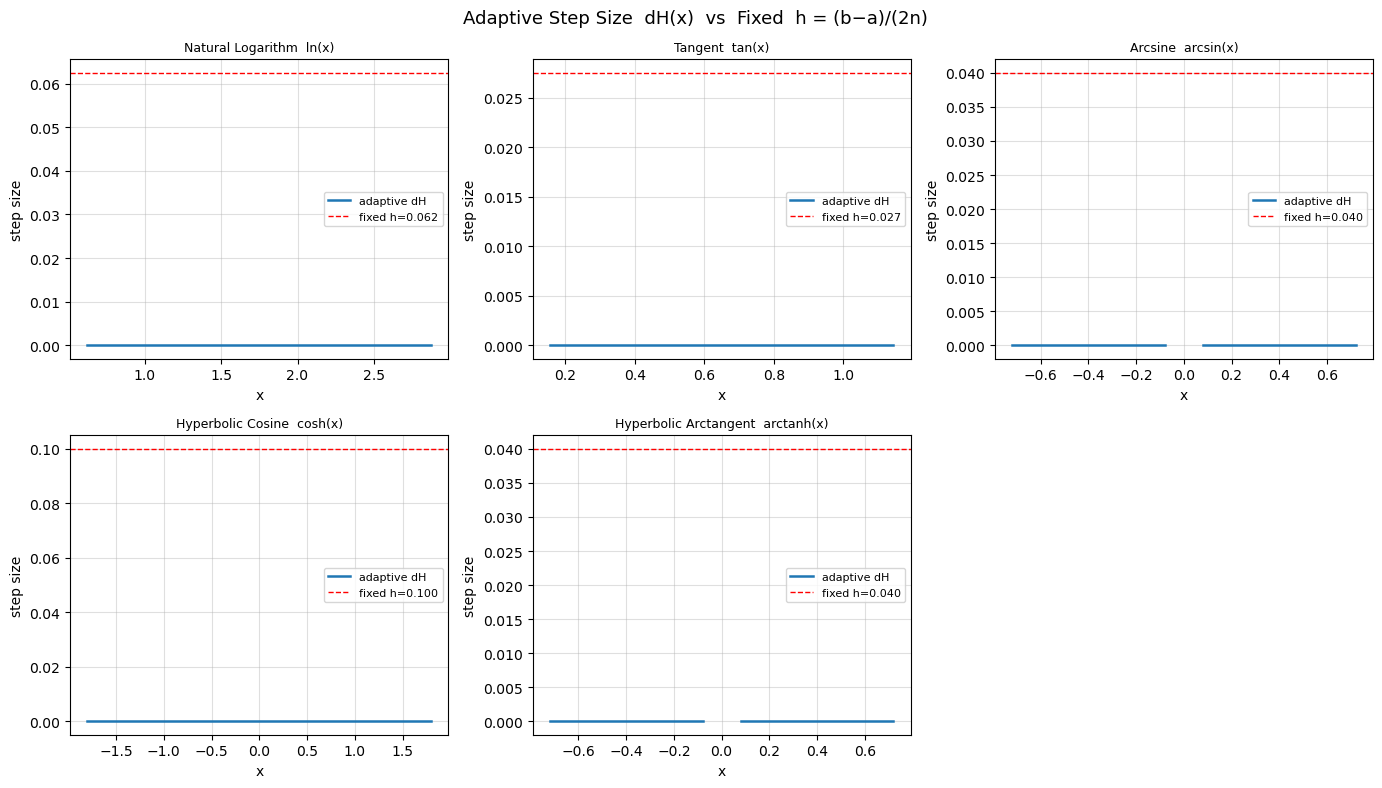

In [10]:
# ── Plot 3: Adaptive dH step size vs fixed h ───────────────────────────────────
# Shows why the adaptive step matters — dh varies significantly across the domain

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
fig.suptitle('Adaptive Step Size  dH(x)  vs  Fixed  h = (b−a)/(2n)', fontsize=13)

for idx, (fid, res) in enumerate(all_results.items()):
    spec  = FUNCTIONS[fid]
    a, b  = spec.default_interval
    fixed = (b - a) / (2 * N)
    ax    = axes[idx]
    ax.plot(res['xj'], res['dH'],              lw=1.8, label='adaptive dH')
    ax.axhline(fixed, color='r', ls='--', lw=1, label=f'fixed h={fixed:.3f}')
    ax.set_title(FUNCTIONS[fid].name, fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('step size')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('adaptive_step.png', dpi=150, bbox_inches='tight')
plt.show()

## Observations

### Derivative approximation
- The adaptive step $dH(x)$ accounts for local curvature via $f''(x)$, yielding near-optimal accuracy across the domain.
- Functions with high curvature (e.g. $\arcsin$ near $\pm 1$, $\text{arctanh}$ near $\pm 1$) show larger errors near domain boundaries — an expected consequence of floating-point cancellation.
- Where $dh(x)$ exceeds the cap $(b-a)/(2n)$, the fixed grid spacing is more conservative and is used instead.

### Integral approximation
- All five functions follow the expected $O(n^{-2})$ convergence rate on the log-log convergence plot — a hallmark of the trapezoidal rule on smooth integrands.
- $\tan(x)$ and $\text{arctanh}(x)$ have slower convergence at modest $n$ because their curvature is higher, requiring more panels to resolve.

### Takeaway
Adaptive step selection for finite differences is a practical necessity, not just a theoretical nicety. A fixed step that works well for $\cosh(x)$ may catastrophically underperform for $\ln(x)$ near the origin.